In [204]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 1000)

In [205]:
df_state = pd.read_csv("data/raw/hhs_state_timeseries.csv")

df_state["previous_day_admission_adult_covid_suspected_80"] = df_state["previous_day_admission_adult_covid_suspected_80_"]
df_state.drop(columns="previous_day_admission_adult_covid_suspected_80_")

,state,date,critical_staffing_shortage_today_yes,critical_staffing_shortage_today_no,critical_staffing_shortage_today_not_reported,critical_staffing_shortage_anticipated_within_week_yes,critical_staffing_shortage_anticipated_within_week_no,critical_staffing_shortage_anticipated_within_week_not_reported,hospital_onset_covid,hospital_onset_covid_coverage,inpatient_beds,inpatient_beds_coverage,inpatient_beds_used,inpatient_beds_used_coverage,inpatient_beds_used_covid,inpatient_beds_used_covid_coverage,previous_day_admission_adult_covid_confirmed,previous_day_admission_adult_covid_confirmed_coverage,previous_day_admission_adult_covid_suspected,previous_day_admission_adult_covid_suspected_coverage,previous_day_admission_pediatric_covid_confirmed,previous_day_admission_pediatric_covid_confirmed_coverage,previous_day_admission_pediatric_covid_suspected,previous_day_admission_pediatric_covid_suspected_coverage,staffed_adult_icu_bed_occupancy,staffed_adult_icu_bed_occupancy_coverage,staffed_icu_adult_patients_confirmed_and_suspected_covid,staffed_icu_adult_patients_confirmed_and_suspected_covid_coverage,staffed_icu_adult_patients_confirmed_covid,staffed_icu_adult_patients_confirmed_covid_coverage,total_adult_patients_hospitalized_confirmed_and_suspected_covid,total_adult_patients_hospitalized_confirmed_and_suspected_covid_coverage,total_adult_patients_hospitalized_confirmed_covid,total_adult_patients_hospitalized_confirmed_covid_coverage,total_pediatric_patients_hospitalized_confirmed_and_suspected_covid,total_pediatric_patients_hospitalized_confirmed_and_suspected_covid_coverage,total_pediatric_patients_hospitalized_confirmed_covid,total_pediatric_patients_hospitalized_confirmed_covid_coverage,total_staffed_adult_icu_beds,total_staffed_adult_icu_beds_coverage,inpatient_beds_utilization,inpatient_beds_utilization_coverage,inpatient_beds_utilization_numerator,inpatient_beds_utilization_denominator,percent_of_inpatients_with_covid,percent_of_inpatients_with_covid_coverage,percent_of_inpatients_with_covid_numerator,percent_of_inpatients_with_covid_denominator,inpatient_bed_covid_utilization,inpatient_bed_covid_utilization_coverage,inpatient_bed_covid_utilization_numerator,inpatient_bed_covid_utilization_denominator,adult_icu_bed_covid_utilization,adult_icu_bed_covid_utilization_coverage,adult_icu_bed_covid_utilization_numerator,adult_icu_bed_covid_utilization_denominator,adult_icu_bed_utilization,adult_icu_bed_utilization_coverage,adult_icu_bed_utilization_numerator,adult_icu_bed_utilization_denominator,geocoded_state,previous_day_admission_adult_covid_confirmed_18_19,previous_day_admission_adult_covid_confirmed_18_19_coverage,previous_day_admission_adult_covid_confirmed_20_29,previous_day_admission_adult_covid_confirmed_20_29_coverage,previous_day_admission_adult_covid_confirmed_30_39,previous_day_admission_adult_covid_confirmed_30_39_coverage,previous_day_admission_adult_covid_confirmed_40_49,previous_day_admission_adult_covid_confirmed_40_49_coverage,previous_day_admission_adult_covid_confirmed_50_59,previous_day_admission_adult_covid_confirmed_50_59_coverage,previous_day_admission_adult_covid_confirmed_60_69,previous_day_admission_adult_covid_confirmed_60_69_coverage,previous_day_admission_adult_covid_confirmed_70_79,previous_day_admission_adult_covid_confirmed_70_79_coverage,previous_day_admission_adult_covid_confirmed_80,previous_day_admission_adult_covid_confirmed_80_coverage,previous_day_admission_adult_covid_confirmed_unknown,previous_day_admission_adult_covid_confirmed_unknown_coverage,previous_day_admission_adult_covid_suspected_18_19,previous_day_admission_adult_covid_suspected_18_19_coverage,previous_day_admission_adult_covid_suspected_20_29,previous_day_admission_adult_covid_suspected_20_29_coverage,previous_day_admission_adult_covid_suspected_30_39,previous_day_admission_adult_covid_suspected_30_39_coverage,previous_day_admission_adult_covid_suspected_40_49,previous_day_admission_adult_covid_suspected_40_49_coverage,previou

1. Combine critical_staffing_shortage_today_yes, critical_staffing_shortage_today_no
2. Combine critical_staffing_shortage_anticipated_within_week_yes, critical_staffing_shortage_anticipated_within_week_no
2. Join hospital dataset for total bedcount


1. state
2. date
3. critical_staffing_shortage_today_yes
4. critical_staffing_shortage_today_no
5. critical_staffing_shortage_today_not_reported	
6. critical_staffing_shortage_anticipated_within_week_yes	
7. critical_staffing_shortage_anticipated_within_week_no
9. inpatient_beds	
10. inpatient_beds_coverage	
11. inpatient_beds_used	
12. inpatient_beds_used_coverage	
13. inpatient_beds_used_covid	
14. inpatient_beds_used_covid_coverage

In [206]:
list(df_state.columns)


['state',
 'date',
 'critical_staffing_shortage_today_yes',
 'critical_staffing_shortage_today_no',
 'critical_staffing_shortage_today_not_reported',
 'critical_staffing_shortage_anticipated_within_week_yes',
 'critical_staffing_shortage_anticipated_within_week_no',
 'critical_staffing_shortage_anticipated_within_week_not_reported',
 'hospital_onset_covid',
 'hospital_onset_covid_coverage',
 'inpatient_beds',
 'inpatient_beds_coverage',
 'inpatient_beds_used',
 'inpatient_beds_used_coverage',
 'inpatient_beds_used_covid',
 'inpatient_beds_used_covid_coverage',
 'previous_day_admission_adult_covid_confirmed',
 'previous_day_admission_adult_covid_confirmed_coverage',
 'previous_day_admission_adult_covid_suspected',
 'previous_day_admission_adult_covid_suspected_coverage',
 'previous_day_admission_pediatric_covid_confirmed',
 'previous_day_admission_pediatric_covid_confirmed_coverage',
 'previous_day_admission_pediatric_covid_suspected',
 'previous_day_admission_pediatric_covid_suspected_

['previous_day_admission_adult_covid_confirmed',
 'previous_day_admission_adult_covid_confirmed_coverage',
 'previous_day_admission_adult_covid_suspected',
 'previous_day_admission_adult_covid_suspected_coverage',
 'previous_day_admission_pediatric_covid_confirmed',
 'previous_day_admission_pediatric_covid_confirmed_coverage',
 'previous_day_admission_pediatric_covid_suspected',
 'previous_day_admission_pediatric_covid_suspected_coverage',
 'staffed_adult_icu_bed_occupancy',
 'staffed_adult_icu_bed_occupancy_coverage',
 'staffed_icu_adult_patients_confirmed_and_suspected_covid',
 'staffed_icu_adult_patients_confirmed_and_suspected_covid_coverage',
 'staffed_icu_adult_patients_confirmed_covid',
 'staffed_icu_adult_patients_confirmed_covid_coverage',
 'total_adult_patients_hospitalized_confirmed_and_suspected_covid',
 'total_adult_patients_hospitalized_confirmed_and_suspected_covid_coverage',
 'total_adult_patients_hospitalized_confirmed_covid',
 'total_adult_patients_hospitalized_confirmed_covid_coverage',
 'total_pediatric_patients_hospitalized_confirmed_and_suspected_covid',
 'total_pediatric_patients_hospitalized_confirmed_and_suspected_covid_coverage',
 'total_pediatric_patients_hospitalized_confirmed_covid',
 'total_pediatric_patients_hospitalized_confirmed_covid_coverage',
 'total_staffed_adult_icu_beds',
 'total_staffed_adult_icu_beds_coverage',
 'adult_icu_bed_covid_utilization',
 'adult_icu_bed_covid_utilization_coverage',
 'adult_icu_bed_covid_utilization_numerator',
 'adult_icu_bed_covid_utilization_denominator',
 'adult_icu_bed_utilization',
 'adult_icu_bed_utilization_coverage',
 'adult_icu_bed_utilization_numerator',
 'adult_icu_bed_utilization_denominator',
 'geocoded_state',
 'previous_day_admission_adult_covid_confirmed_18_19',
 'previous_day_admission_adult_covid_confirmed_18_19_coverage',
 'previous_day_admission_adult_covid_confirmed_20_29',
 'previous_day_admission_adult_covid_confirmed_20_29_coverage',
 'previous_day_admission_adult_covid_confirmed_30_39',
 'previous_day_admission_adult_covid_confirmed_30_39_coverage',
 'previous_day_admission_adult_covid_confirmed_40_49',
 'previous_day_admission_adult_covid_confirmed_40_49_coverage',
 'previous_day_admission_adult_covid_confirmed_50_59',
 'previous_day_admission_adult_covid_confirmed_50_59_coverage',
 'previous_day_admission_adult_covid_confirmed_60_69',
 'previous_day_admission_adult_covid_confirmed_60_69_coverage',
 'previous_day_admission_adult_covid_confirmed_70_79',
 'previous_day_admission_adult_covid_confirmed_70_79_coverage',
 'previous_day_admission_adult_covid_confirmed_80',
 'previous_day_admission_adult_covid_confirmed_80_coverage',
 'previous_day_admission_adult_covid_confirmed_unknown',
 'previous_day_admission_adult_covid_confirmed_unknown_coverage',
 'previous_day_admission_adult_covid_suspected_18_19',
 'previous_day_admission_adult_covid_suspected_18_19_coverage',
 'previous_day_admission_adult_covid_suspected_20_29',
 'previous_day_admission_adult_covid_suspected_20_29_coverage',
 'previous_day_admission_adult_covid_suspected_30_39',
 'previous_day_admission_adult_covid_suspected_30_39_coverage',
 'previous_day_admission_adult_covid_suspected_40_49',
 'previous_day_admission_adult_covid_suspected_40_49_coverage',
 'previous_day_admission_adult_covid_suspected_50_59',
 'previous_day_admission_adult_covid_suspected_50_59_coverage',
 'previous_day_admission_adult_covid_suspected_60_69',
 'previous_day_admission_adult_covid_suspected_60_69_coverage',
 'previous_day_admission_adult_covid_suspected_70_79',
 'previous_day_admission_adult_covid_suspected_70_79_coverage',
 'previous_day_admission_adult_covid_suspected_80_',
 'previous_day_admission_adult_covid_suspected_80_coverage',
 'previous_day_admission_adult_covid_suspected_unknown',
 'previous_day_admission_adult_covid_suspected_unknown_coverage',
 'previous_week_therapeutic_a_casirivimab_imdevimab_courses_used',
 'previous_week_therapeutic_b_bamlanivimab_courses_used',
 'previous_week_therapeutic_c_bamlanivimab_etesevimab_courses_used',
 'previous_day_admission_influenza_confirmed',
 'previous_day_admission_influenza_confirmed_coverage',
 'previous_day_deaths_covid_and_influenza',
 'previous_day_deaths_covid_and_influenza_coverage',
 'previous_day_deaths_influenza',
 'previous_day_deaths_influenza_coverage',
 'all_pediatric_inpatient_bed_occupied',
 'all_pediatric_inpatient_bed_occupied_coverage',
 'all_pediatric_inpatient_beds',
 'all_pediatric_inpatient_beds_coverage',
 'previous_day_admission_pediatric_covid_confirmed_0_4',
 'previous_day_admission_pediatric_covid_confirmed_0_4_coverage',
 'previous_day_admission_pediatric_covid_confirmed_12_17',
 'previous_day_admission_pediatric_covid_confirmed_12_17_coverage',
 'previous_day_admission_pediatric_covid_confirmed_5_11',
 'previous_day_admission_pediatric_covid_confirmed_5_11_coverage',
 'previous_day_admission_pediatric_covid_confirmed_unknown',
 'previous_day_admission_pediatric_covid_confirmed_unknown_coverage',
 'staffed_icu_pediatric_patients_confirmed_covid',
 'staffed_icu_pediatric_patients_confirmed_covid_coverage',
 'staffed_pediatric_icu_bed_occupancy',
 'staffed_pediatric_icu_bed_occupancy_coverage',
 'total_staffed_pediatric_icu_beds',
 'total_staffed_pediatric_icu_beds_coverage']

## Preprocessing

In [207]:
# to_delete = ['previous_day_admission_adult_covid_confirmed',
#  'previous_day_admission_adult_covid_confirmed_coverage',
#  'previous_day_admission_adult_covid_suspected',
#  'previous_day_admission_adult_covid_suspected_coverage',
#  'previous_day_admission_pediatric_covid_confirmed',
#  'previous_day_admission_pediatric_covid_confirmed_coverage',
#  'previous_day_admission_pediatric_covid_suspected',
#  'previous_day_admission_pediatric_covid_suspected_coverage',
#  'staffed_adult_icu_bed_occupancy',
#  'staffed_adult_icu_bed_occupancy_coverage',
#  'staffed_icu_adult_patients_confirmed_and_suspected_covid',
#  'staffed_icu_adult_patients_confirmed_and_suspected_covid_coverage',
#  'staffed_icu_adult_patients_confirmed_covid',
#  'staffed_icu_adult_patients_confirmed_covid_coverage',
#  'total_adult_patients_hospitalized_confirmed_and_suspected_covid',
#  'total_adult_patients_hospitalized_confirmed_and_suspected_covid_coverage',
#  'total_adult_patients_hospitalized_confirmed_covid',
#  'total_adult_patients_hospitalized_confirmed_covid_coverage',
#  'total_pediatric_patients_hospitalized_confirmed_and_suspected_covid',
#  'total_pediatric_patients_hospitalized_confirmed_and_suspected_covid_coverage',
#  'total_pediatric_patients_hospitalized_confirmed_covid',
#  'total_pediatric_patients_hospitalized_confirmed_covid_coverage',
#  'total_staffed_adult_icu_beds',
#  'total_staffed_adult_icu_beds_coverage',
#  'adult_icu_bed_covid_utilization',
#  'adult_icu_bed_covid_utilization_coverage',
#  'adult_icu_bed_covid_utilization_numerator',
#  'adult_icu_bed_covid_utilization_denominator',
#  'adult_icu_bed_utilization',
#  'adult_icu_bed_utilization_coverage',
#  'adult_icu_bed_utilization_numerator',
#  'adult_icu_bed_utilization_denominator',
#  'geocoded_state',
#  'previous_day_admission_adult_covid_confirmed_18_19',
#  'previous_day_admission_adult_covid_confirmed_18_19_coverage',
#  'previous_day_admission_adult_covid_confirmed_20_29',
#  'previous_day_admission_adult_covid_confirmed_20_29_coverage',
#  'previous_day_admission_adult_covid_confirmed_30_39',
#  'previous_day_admission_adult_covid_confirmed_30_39_coverage',
#  'previous_day_admission_adult_covid_confirmed_40_49',
#  'previous_day_admission_adult_covid_confirmed_40_49_coverage',
#  'previous_day_admission_adult_covid_confirmed_50_59',
#  'previous_day_admission_adult_covid_confirmed_50_59_coverage',
#  'previous_day_admission_adult_covid_confirmed_60_69',
#  'previous_day_admission_adult_covid_confirmed_60_69_coverage',
#  'previous_day_admission_adult_covid_confirmed_70_79',
#  'previous_day_admission_adult_covid_confirmed_70_79_coverage',
#  'previous_day_admission_adult_covid_confirmed_80',
#  'previous_day_admission_adult_covid_confirmed_80_coverage',
#  'previous_day_admission_adult_covid_confirmed_unknown',
#  'previous_day_admission_adult_covid_confirmed_unknown_coverage',
#  'previous_day_admission_adult_covid_suspected_18_19',
#  'previous_day_admission_adult_covid_suspected_18_19_coverage',
#  'previous_day_admission_adult_covid_suspected_20_29',
#  'previous_day_admission_adult_covid_suspected_20_29_coverage',
#  'previous_day_admission_adult_covid_suspected_30_39',
#  'previous_day_admission_adult_covid_suspected_30_39_coverage',
#  'previous_day_admission_adult_covid_suspected_40_49',
#  'previous_day_admission_adult_covid_suspected_40_49_coverage',
#  'previous_day_admission_adult_covid_suspected_50_59',
#  'previous_day_admission_adult_covid_suspected_50_59_coverage',
#  'previous_day_admission_adult_covid_suspected_60_69',
#  'previous_day_admission_adult_covid_suspected_60_69_coverage',
#  'previous_day_admission_adult_covid_suspected_70_79',
#  'previous_day_admission_adult_covid_suspected_70_79_coverage',
#  'previous_day_admission_adult_covid_suspected_80_',
#  'previous_day_admission_adult_covid_suspected_80_coverage',
#  'previous_day_admission_adult_covid_suspected_unknown',
#  'previous_day_admission_adult_covid_suspected_unknown_coverage',
#  'previous_week_therapeutic_a_casirivimab_imdevimab_courses_used',
#  'previous_week_therapeutic_b_bamlanivimab_courses_used',
#  'previous_week_therapeutic_c_bamlanivimab_etesevimab_courses_used',
#  'previous_day_admission_influenza_confirmed',
#  'previous_day_admission_influenza_confirmed_coverage',
#  'previous_day_deaths_covid_and_influenza',
#  'previous_day_deaths_covid_and_influenza_coverage',
#  'previous_day_deaths_influenza',
#  'previous_day_deaths_influenza_coverage',
#  'all_pediatric_inpatient_bed_occupied',
#  'all_pediatric_inpatient_bed_occupied_coverage',
#  'all_pediatric_inpatient_beds',
#  'all_pediatric_inpatient_beds_coverage',
#  'previous_day_admission_pediatric_covid_confirmed_0_4',
#  'previous_day_admission_pediatric_covid_confirmed_0_4_coverage',
#  'previous_day_admission_pediatric_covid_confirmed_12_17',
#  'previous_day_admission_pediatric_covid_confirmed_12_17_coverage',
#  'previous_day_admission_pediatric_covid_confirmed_5_11',
#  'previous_day_admission_pediatric_covid_confirmed_5_11_coverage',
#  'previous_day_admission_pediatric_covid_confirmed_unknown',
#  'previous_day_admission_pediatric_covid_confirmed_unknown_coverage',
#  'staffed_icu_pediatric_patients_confirmed_covid',
#  'staffed_icu_pediatric_patients_confirmed_covid_coverage',
#  'staffed_pediatric_icu_bed_occupancy',
#  'staffed_pediatric_icu_bed_occupancy_coverage',
#  'total_staffed_pediatric_icu_beds',
#  'total_staffed_pediatric_icu_beds_coverage']

In [208]:
to_delete = [
 'staffed_adult_icu_bed_occupancy',
 'staffed_adult_icu_bed_occupancy_coverage',
 'staffed_icu_adult_patients_confirmed_and_suspected_covid',
 'staffed_icu_adult_patients_confirmed_and_suspected_covid_coverage',
 'staffed_icu_adult_patients_confirmed_covid',
 'staffed_icu_adult_patients_confirmed_covid_coverage',
 'total_adult_patients_hospitalized_confirmed_and_suspected_covid',
 'total_adult_patients_hospitalized_confirmed_and_suspected_covid_coverage',
 'total_adult_patients_hospitalized_confirmed_covid',
 'total_adult_patients_hospitalized_confirmed_covid_coverage',
 'total_pediatric_patients_hospitalized_confirmed_and_suspected_covid',
 'total_pediatric_patients_hospitalized_confirmed_and_suspected_covid_coverage',
 'total_pediatric_patients_hospitalized_confirmed_covid',
 'total_pediatric_patients_hospitalized_confirmed_covid_coverage',
 'total_staffed_adult_icu_beds',
 'total_staffed_adult_icu_beds_coverage',
 'adult_icu_bed_covid_utilization',
 'adult_icu_bed_covid_utilization_coverage',
 'adult_icu_bed_covid_utilization_numerator',
 'adult_icu_bed_covid_utilization_denominator',
 'adult_icu_bed_utilization',
 'adult_icu_bed_utilization_coverage',
 'adult_icu_bed_utilization_numerator',
 'adult_icu_bed_utilization_denominator',
 'geocoded_state',
 'all_pediatric_inpatient_bed_occupied',
 'all_pediatric_inpatient_bed_occupied_coverage',
 'all_pediatric_inpatient_beds',
 'all_pediatric_inpatient_beds_coverage',
 'staffed_icu_pediatric_patients_confirmed_covid',
 'staffed_icu_pediatric_patients_confirmed_covid_coverage',
 'staffed_pediatric_icu_bed_occupancy',
 'staffed_pediatric_icu_bed_occupancy_coverage',
 'total_staffed_pediatric_icu_beds',
 'total_staffed_pediatric_icu_beds_coverage']

In [209]:
df_state = df_state.drop(columns= to_delete)

In [210]:
df_state.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81713 entries, 0 to 81712
Columns: 101 entries, state to previous_day_admission_adult_covid_suspected_80
dtypes: float64(56), int64(43), object(2)
memory usage: 63.0+ MB


In [211]:
df_state[["on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses", "inpatient_beds_used"]].corr()

,on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses,inpatient_beds_used
on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses,1.000000,0.459746
inpatient_beds_used,0.459746,1.000000


In [212]:
df_state[["on_hand_supply_therapeutic_b_bamlanivimab_courses", "inpatient_beds_used"]].corr()

,on_hand_supply_therapeutic_b_bamlanivimab_courses,inpatient_beds_used
on_hand_supply_therapeutic_b_bamlanivimab_courses,1.000000,0.333326
inpatient_beds_used,0.333326,1.000000


In [213]:
df_state[["on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses", "inpatient_beds_used"]].corr()

,on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses,inpatient_beds_used
on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses,1.000000,0.361163
inpatient_beds_used,0.361163,1.000000


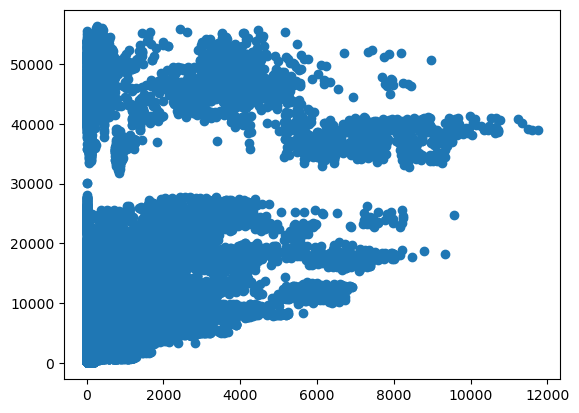

In [214]:
plt.scatter(x = df_state["on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses"], y = df_state["inpatient_beds_used"])

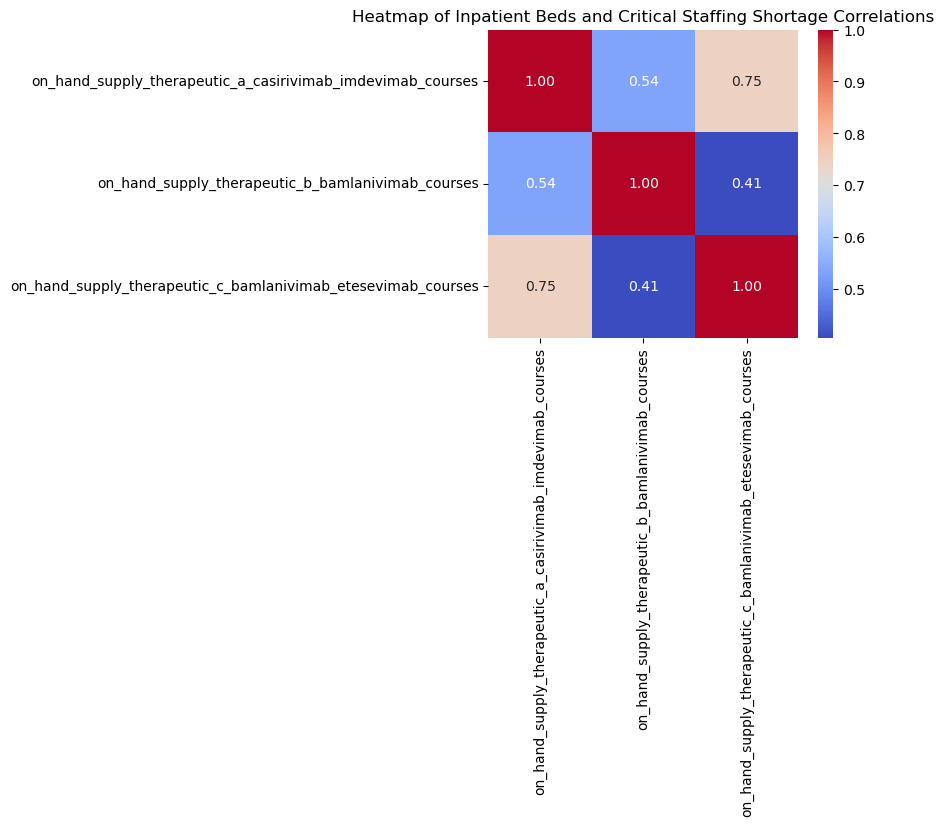

In [215]:
corr_mat = (df_state.loc[:, df_state.columns.isin(["on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses", "on_hand_supply_therapeutic_b_bamlanivimab_courses", 
                                                   "on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses"])]).corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap of Inpatient Beds and Critical Staffing Shortage Correlations")
plt.show()

In [216]:
# Removing these 3 columns as they are moderate and positively correlated  with inpatient beds used for covid
# df_state = df_state.drop(columns = ["on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses", "on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses", 
#                "on_hand_supply_therapeutic_b_bamlanivimab_courses"])



In [217]:
#Explains the same information as the percentage thats caculated with these numerators and denominators.
df_state = df_state.drop(columns = [
                        "percent_of_inpatients_with_covid",
                         "percent_of_inpatients_with_covid_coverage",
                         "inpatient_bed_covid_utilization",
                         "inpatient_bed_covid_utilization_coverage",
                         ])

# "inpatient_beds_utilization_coverage", 
# "inpatient_beds_utilization",

# Feature Engineering

In [218]:
# Coverage per state (row wise)
df_state["coverage_per_state"] = df_state["critical_staffing_shortage_today_yes"] + df_state["critical_staffing_shortage_today_no"] + df_state["critical_staffing_shortage_today_not_reported"]


In [219]:
# Normalized deaths per hostpital from covid 
df_state["hospital_covid_deaths"] = df_state["deaths_covid"] / df_state["deaths_covid_coverage"] 

# Staffing shortage ratio
df_state["state_staffing_shortage_ratio"] = df_state["critical_staffing_shortage_today_yes"] / (df_state["critical_staffing_shortage_today_yes"] + df_state["critical_staffing_shortage_today_no"])

# Reporting completeness
df_state["state_staffing_reporting_completeness"] = (df_state["critical_staffing_shortage_today_yes"] + df_state["critical_staffing_shortage_today_no"]) / (
    df_state["coverage_per_state"]
)

# Reporting for next week (staffing shortage) ratio
df_state["state_staffing_shortage_anticipation_ratio"] = df_state["critical_staffing_shortage_anticipated_within_week_yes"] / (
    df_state["critical_staffing_shortage_anticipated_within_week_yes"]
    + df_state["critical_staffing_shortage_anticipated_within_week_no"]
)

# Reporting for next week (staffing shortage) completeness
df_state["state_staffing_shortage_anticipation_completeness"] = (df_state["critical_staffing_shortage_anticipated_within_week_yes"] + df_state["critical_staffing_shortage_anticipated_within_week_no"]) / (
    df_state["critical_staffing_shortage_anticipated_within_week_yes"] + df_state["critical_staffing_shortage_anticipated_within_week_no"] + df_state["critical_staffing_shortage_anticipated_within_week_not_reported"] )

In [220]:
df_state = df_state.drop(columns = ["deaths_covid_coverage", 
                                    "deaths_covid", 
                                    "critical_staffing_shortage_today_yes", 
                                    "critical_staffing_shortage_today_no", 
                                    "critical_staffing_shortage_today_not_reported",
                                    "critical_staffing_shortage_anticipated_within_week_yes", 
                                    "critical_staffing_shortage_anticipated_within_week_no",
                                    "critical_staffing_shortage_anticipated_within_week_not_reported"]
                                    )

In [221]:
# Remove hospital_onset_covid as feature as it a subset of the inpatient_beds used. If hospital onset covid increases, then inpatient beds used must increase. Trivial predictor to use and 
# has the same goal of "measure hospital activity" as inpatient beds used. OR wait, maybe thats what inpatient_beds_used_covid is doing but hospital_onset_covid doesnt mean that the covid patient 
# MUST use a bed

df_state = df_state.drop(columns= ["hospital_onset_covid", "hospital_onset_covid_coverage"])

In [222]:
# Normalized beds total per hospital 
df_state["hospital_inpatient_beds"] = df_state["inpatient_beds"] / (df_state["inpatient_beds_coverage"])

# Normalized beds used per hospital
df_state["hospital_inpatient_beds_used"] = df_state["inpatient_beds_used"] / df_state["inpatient_beds_used_coverage"]

# Subset of our response varible, inpatient beds used
df_state = df_state.drop(columns = ["inpatient_beds_used_covid", "inpatient_beds_used_covid_coverage"])

#normalize count of total icu patients
df_state["hospital_patients_hospitalized_confirmed_influenza"] = df_state["total_patients_hospitalized_confirmed_influenza"] / df_state["total_patients_hospitalized_confirmed_influenza_coverage"]

#Normalized count for covid plus influenza patients
df_state["hospital_patients_hospitalized_confirmed_influenza_and_covid"] = df_state["total_patients_hospitalized_confirmed_influenza_and_covid"] / df_state["total_patients_hospitalized_confirmed_influenza_and_covid_coverage"]

#ICU is a subset of hospitalized with influenza, 
df_state = df_state.drop(columns = ["inpatient_beds_coverage", "inpatient_beds_used_coverage", 
"icu_patients_confirmed_influenza_coverage", "total_patients_hospitalized_confirmed_influenza_coverage", "total_patients_hospitalized_confirmed_influenza_and_covid_coverage",
"total_patients_hospitalized_confirmed_influenza_and_covid", "total_patients_hospitalized_confirmed_influenza"])

In [223]:
def normalize_cols(df:pd.DataFrame):
    df_normalized = df.copy()
    for col in df.columns:
        if "_coverage" in col:
            new_name = col.replace("_coverage", "")
            normalized = df[new_name] / df[col]
            df_normalized[new_name + "_normalized"] = normalized
            df_normalized = df_normalized.drop(columns=[col, new_name])
        elif '_utilization' in col:
            df_normalized.drop(columns=col)
        else:
            continue
    return df_normalized
df_normalized = normalize_cols(df_state)
df_normalized


,state,date,inpatient_beds,inpatient_beds_used,inpatient_beds_utilization_numerator,inpatient_beds_utilization_denominator,percent_of_inpatients_with_covid_numerator,percent_of_inpatients_with_covid_denominator,inpatient_bed_covid_utilization_numerator,inpatient_bed_covid_utilization_denominator,previous_day_admission_adult_covid_suspected_80_,on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses,on_hand_supply_therapeutic_b_bamlanivimab_courses,on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses,previous_week_therapeutic_a_casirivimab_imdevimab_courses_used,previous_week_therapeutic_b_bamlanivimab_courses_used,previous_week_therapeutic_c_bamlanivimab_etesevimab_courses_used,icu_patients_confirmed_influenza,coverage_per_state,hospital_covid_deaths,state_staffing_shortage_ratio,state_staffing_reporting_completeness,state_staffing_shortage_anticipation_ratio,state_staffing_shortage_anticipation_completeness,hospital_inpatient_beds,hospital_inpatient_beds_used,hospital_patients_hospitalized_confirmed_influenza,hospital_patients_hospitalized_confirmed_influenza_and_covid,previous_day_admission_adult_covid_confirmed_normalized,previous_day_admission_adult_covid_suspected_normalized,previous_day_admission_pediatric_covid_confirmed_normalized,previous_day_admission_pediatric_covid_suspected_normalized,inpatient_beds_utilization_normalized,previous_day_admission_adult_covid_confirmed_18_19_normalized,previous_day_admission_adult_covid_confirmed_20_29_normalized,previous_day_admission_adult_covid_confirmed_30_39_normalized,previous_day_admission_adult_covid_confirmed_40_49_normalized,previous_day_admission_adult_covid_confirmed_50_59_normalized,previous_day_admission_adult_covid_confirmed_60_69_normalized,previous_day_admission_adult_covid_confirmed_70_79_normalized,previous_day_admission_adult_covid_confirmed_80_normalized,previous_day_admission_adult_covid_confirmed_unknown_normalized,previous_day_admission_adult_covid_suspected_18_19_normalized,previous_day_admission_adult_covid_suspected_20_29_normalized,previous_day_admission_adult_covid_suspected_30_39_normalized,previous_day_admission_adult_covid_suspected_40_49_normalized,previous_day_admission_adult_covid_suspected_50_59_normalized,previous_day_admission_adult_covid_suspected_60_69_normalized,previous_day_admission_adult_covid_suspected_70_79_normalized,previous_day_admission_adult_covid_suspected_80_normalized,previous_day_admission_adult_covid_suspected_unknown_normalized,previous_day_admission_influenza_confirmed_normalized,previous_day_deaths_covid_and_influenza_normalized,previous_day_deaths_influenza_normalized,previous_day_admission_pediatric_covid_confirmed_0_4_normalized,previous_day_admission_pediatric_covid_confirmed_12_17_normalized,previous_day_admission_pediatric_covid_confirmed_5_11_normalized,previous_day_admission_pediatric_covid_confirmed_unknown_normalized
0,AL,2020-01-01T00:00:00.000,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,0.000000,NaN,0.000000,6.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HI,2020-01-01T00:00:00.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.0,NaN,0.000000,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IN,2020-01-01T00:00:00.000,30.0,15.0,15.0,30.0,0.0,15.0,0.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.0,NaN,0.000000,NaN,0.000000,30.000000,15.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LA,2020-01-01T00:00:00.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MN,2020-01-01T00:00:00.00

## Final column drop of highly correlated or irrelevant features

In [224]:
df_normalized = df_normalized.drop(columns = ["inpatient_beds_utilization_numerator",
"inpatient_beds_utilization_denominator",
'percent_of_inpatients_with_covid_numerator',
'percent_of_inpatients_with_covid_denominator',
'inpatient_bed_covid_utilization_numerator',
'inpatient_bed_covid_utilization_denominator',]
       )

In [225]:
#hospital_patients_hospitalized_confirmed_influenza is a subset of hospital_patients_hospitalized_confirmed_influenza_and_covid
df_normalized = df_normalized.drop(columns = ["hospital_patients_hospitalized_confirmed_influenza"])

### Final List of acceptable columns

For modeling rate use inpatient_beds_utilization without 'state', 'date', inpatient_beds', 'inpatient_beds_used',
        'inpatient_beds_utilization_coverage',hospital_inpatient_beds_used


for modeling continous rv like hospital_inpatient_beds_used, exclude: "state", "date", 'inpatient_beds', 'inpatient_beds_used',
       'inpatient_beds_utilization', 'inpatient_beds_utilization_coverage'

In [226]:
final_cols = list(df_normalized.columns)
df_normalized.columns

Index(['state', 'date', 'inpatient_beds', 'inpatient_beds_used',
       'previous_day_admission_adult_covid_suspected_80_',
       'on_hand_supply_therapeutic_a_casirivimab_imdevimab_courses',
       'on_hand_supply_therapeutic_b_bamlanivimab_courses',
       'on_hand_supply_therapeutic_c_bamlanivimab_etesevimab_courses',
       'previous_week_therapeutic_a_casirivimab_imdevimab_courses_used',
       'previous_week_therapeutic_b_bamlanivimab_courses_used',
       'previous_week_therapeutic_c_bamlanivimab_etesevimab_courses_used',
       'icu_patients_confirmed_influenza', 'coverage_per_state',
       'hospital_covid_deaths', 'state_staffing_shortage_ratio',
       'state_staffing_reporting_completeness',
       'state_staffing_shortage_anticipation_ratio',
       'state_staffing_shortage_anticipation_completeness',
       'hospital_inpatient_beds', 'hospital_inpatient_beds_used',
       'hospital_patients_hospitalized_confirmed_influenza_and_covid',
       'previous_day_admission_adult

In [227]:
df_normalized[final_cols].to_csv('data/clean/final_featuresv2.csv', index=False)
